# Filtering TM/TR CDF plot (tvkern 0609)

Based on the 0604 tvkern notebook. This version reads the full camd9554n1 data pulled back to af309 and supports `nsampRatio/nsamp` result directories.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260615"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle0"
TR_MARKER_MAX = 30

# Previous cgnr6760pn2 root, kept for audit and intentionally not used:
# /astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/output_tvkern_filt_dsub/20260615-141629-tvkern-dsub/shuffle0
RUN_ROOT_OVERRIDES = {
    "cgnr6760pn2": Path("/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/output_tvkern_filt_dsub/20260615-193641-tvkern-dsub-logfix") / SHUFFLE_SELECT,
}


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host]
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/output_tvkern_filt_dsub")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / shuffle_select
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP-tvkern-dsub" / shuffle_select

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]

QUANTILE_DROP = 0.99
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {'tvkern': 'Synthetic Timer-Variance Kernel (dsub)'}
HOST_LABELS = {'camd9554n1': 'AMD EPYC 9554', 'camd9554n2': 'AMD EPYC 9554', 'c920bn3': 'Kunpeng 920B', 'cgnr6760pn2': 'Intel Xeon 6760P'}
OUT_DIR.mkdir(parents=True, exist_ok=True)

for root in DATA_FOLDERS:
    print(root)
print('host_order:', HOST_ORDER)


/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/output_tvkern_filt_dsub/20260615-193641-tvkern-dsub-logfix/shuffle0
/astrum/home/hpchzy/code/data/20260615/camd9554n1/output_tvkern_filt_dsub/20260615-141629-tvkern-dsub/shuffle0
/astrum/home/hpchzy/code/data/20260615/c920bn3/output_tvkern_filt_dsub/20260615-141629-tvkern-dsub/shuffle0
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']


In [3]:
def parse_filt_dir(path):
    name = path.name
    known_timers = sorted(TIMER_LABELS, key=len, reverse=True)
    for timer in known_timers:
        patterns = [
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<ratio>[0-9.]+)_nsamp(?P<nsamp>\d+)_filt$',
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_filt$',
        ]
        for pat in patterns:
            m = re.match(pat, name)
            if m:
                d = m.groupdict()
                d['timer'] = timer
                d['np'] = int(d['np'])
                d['size'] = int(d['size'])
                d['ratio'] = float(d.get('ratio') or np.nan)
                d['nsamp'] = int(d.get('nsamp') or 0)
                return d
    return None


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    return df['ns'].dropna().to_numpy()


def read_hist(hist_file):
    df = pd.read_csv(hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df = df[df['prob'] > 0]
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    df['cdf'] = df['prob'].cumsum()
    df = df[df['cdf'] <= QUANTILE_DROP].copy()
    if not df.empty:
        first = pd.DataFrame({'ns': [df['ns'].iloc[0]], 'prob': [0.0], 'cdf': [0.0]})
        df = pd.concat([first, df], ignore_index=True)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        tm_hist_file = filt_dir / 'tm_hist.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tm_hist_file': tm_hist_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)


entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
print(f'entries: {len(entries)}')

entries = entries[(entries['timer'] != 'cntvct') & (entries['timer'] != 'tsc_native')]
entries.head(20)


entries: 396


,kernel,np,size,ratio,nsamp,timer,host,data_folder,shuffle,filt_dir,tm_file,tm_hist_file,tr_hist_file
264,tvkern,64,0,0.5,20474,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
308,tvkern,64,0,0.5,20039,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
330,tvkern,64,0,0.5,20882,papi,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
352,tvkern,64,0,0.5,20880,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
374,tvkern,64,0,0.5,20447,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
265,tvkern,64,0,0.8,20505,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
309,tvkern,64,0,0.8,20068,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
331,tvkern,64,0,0.8,20911,papi,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
353,tvkern,64,0,0.8,20909,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...
375,tvkern,64,0,0.8,20476,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260615/c920bn3...,shuffle0,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...,/astrum/home/hpchzy/code/data/20260615/c920bn3...


# ER/EP/Wasserstein summary


In [4]:
def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def wd_to_min(hist_file):
    df = read_hist(hist_file)
    if df.empty:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['prob'].to_numpy(dtype=float)
    if pr.sum() <= 0:
        return np.nan
    return np.sum(np.abs(ns - ns.min()) * pr) / pr.sum()


summary_rows = []
for _, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    summary_rows.append({
        **row.to_dict(),
        'ep': read_float_file(filt_folder / 'ep.out'),
        'er': read_float_file(filt_folder / 'er.out'),
        'wd': read_float_file(filt_folder / 'wd.out'),
        'tm_wd_to_min': wd_to_min(filt_folder / 'tm_hist.csv'),
        'tr_wd_to_min': wd_to_min(filt_folder / 'tr_hist.csv'),
    })

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df['timer_label'] = df['timer'].map(TIMER_LABELS).fillna(df['timer'])
df['kernel_label'] = df['kernel'].map(KERNEL_LABELS).fillna(df['kernel'])
df.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ratio', 'nsamp', 'ep', 'er', 'wd', 'tm_wd_to_min', 'tr_wd_to_min']].head(20)


,host,kernel,timer,np,size,ratio,nsamp,ep,er,wd,tm_wd_to_min,tr_wd_to_min
0,c920bn3,tvkern,cgt,64,0,0.5,20474,0.008339,0.000434,3.063317,44.895880,44.895896
1,c920bn3,tvkern,cntvcto,64,0,0.5,20039,0.000377,0.000580,4.010050,21.813426,21.813418
2,c920bn3,tvkern,papi,64,0,0.5,20882,0.010773,0.001245,8.983920,56.338995,56.339067
3,c920bn3,tvkern,papix6,64,0,0.5,20880,0.000000,0.005300,38.145729,72.031557,34.226903
4,c920bn3,tvkern,wtime,64,0,0.5,20447,0.000000,0.006264,44.376884,98.238928,72.664791
5,c920bn3,tvkern,cgt,64,0,0.8,20505,0.008339,0.000649,4.582915,44.895880,44.895896
6,c920bn3,tvkern,cntvcto,64,0,0.8,20068,0.000377,0.001191,8.232161,21.813426,21.813418
7,c920bn3,tvkern,papi,64,0,0.8,20911,0.010773,0.001147,8.276382,56.338995,56.339067
8,c920bn3,tvkern,papix6,64,0,0.8,20909,0.000000,0.005728,41.219095,72.031557,32.862749
9,c920bn3,tvkern,wtime,64,0,0.8,20476,0.000000,0.004734,33.538693,98.238928,72.377015


/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_summary_shuffle0_ratio0.5.png


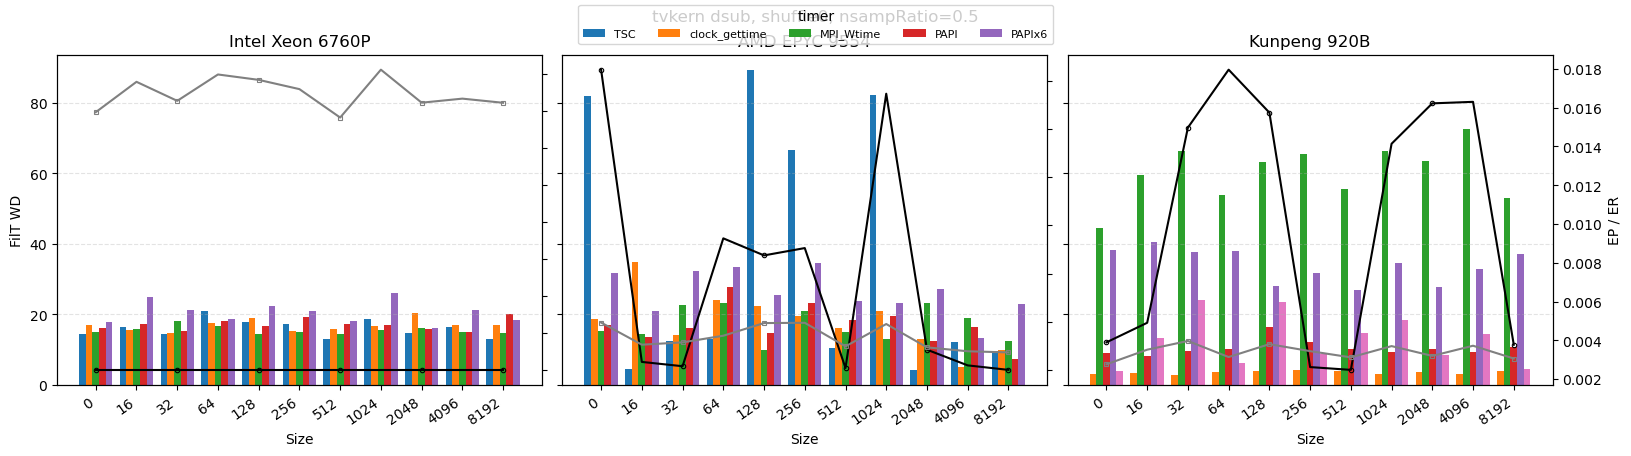

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_summary_shuffle0_ratio0.8.png


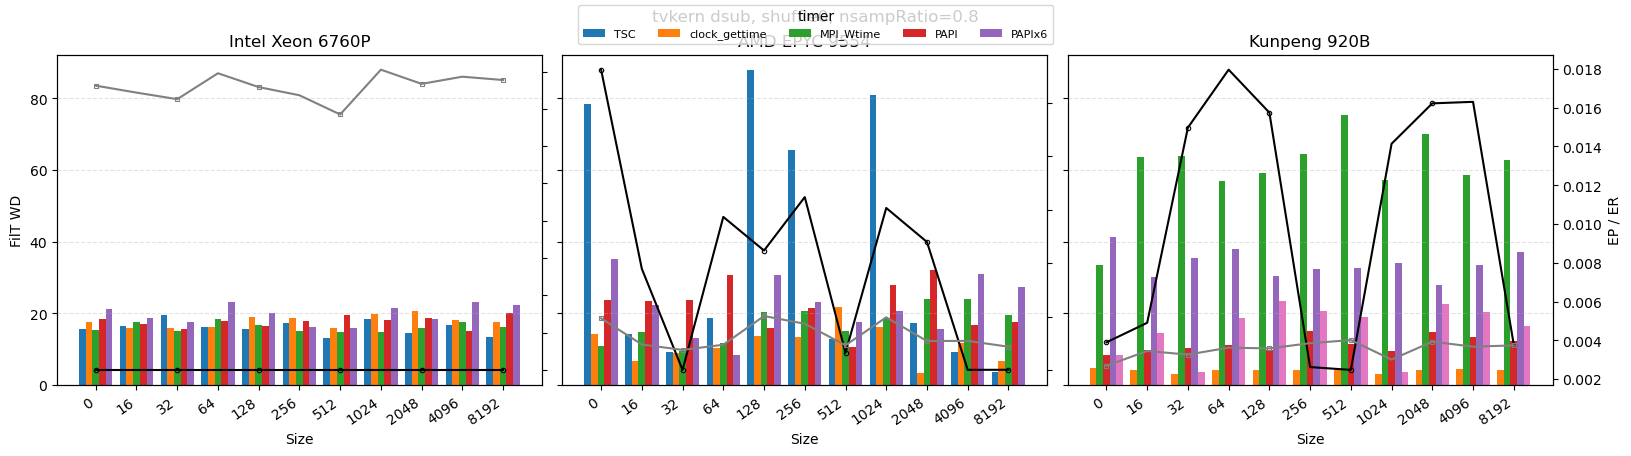

In [5]:
metric_bar = 'wd'
line_metrics = ['ep', 'er']

for ratio, ratio_df in df.groupby('ratio', sort=True):
    plot_df = ratio_df.copy()
    plot_df['size_str'] = plot_df['size'].astype(str)
    size_order = [str(x) for x in sorted(plot_df['size'].unique())]
    plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

    hosts = [host for host in HOST_ORDER if host in set(plot_df['host'])]
    if not hosts:
        continue
    fig, axes = plt.subplots(1, len(hosts), figsize=(5.4 * len(hosts), 4.2), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax1, host in zip(axes, hosts):
        host_df = plot_df[plot_df['host'] == host].copy()
        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)

        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            ax1.bar(x + offset, sub[metric_bar], width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))

        ax1.set_title(HOST_LABELS.get(host, host))
        ax1.set_xlabel('Size')
        ax1.set_xticks(x)
        ax1.set_xticklabels(size_order, rotation=35, ha='right')
        ax1.grid(axis='y', linestyle='--', alpha=0.35)
        if ax1 is axes[0]:
            ax1.set_ylabel('FilT WD')

        ax2 = ax1.twinx()
        line_df = host_df.groupby('size_str', observed=True)[line_metrics].mean().reindex(size_order)
        ax2.plot(x, line_df['ep'], marker='o', markevery=2, markersize=3.2, markerfacecolor='none', markeredgewidth=0.8, label='EP', color='black')
        ax2.plot(x, line_df['er'], marker='s', markevery=2, markersize=3.2, markerfacecolor='none', markeredgewidth=0.8, label='ER', color='gray')
        if ax1 is axes[-1]:
            ax2.set_ylabel('EP / ER')
        else:
            ax2.set_yticklabels([])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='timer', ncol=min(6, max(1, len(labels))), fontsize=8, loc='upper center')
    fig.suptitle(f'tvkern dsub, {SHUFFLE_SELECT}, nsampRatio={ratio:g}', y=1.05)

    if SAVE_FIG:
        out = OUT_DIR / f'tvkern_dsub_summary_{SHUFFLE_SELECT}_ratio{ratio:g}.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)
    plt.show()


# TM/TR CDF plots


/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size0_ratio0.5_tm_tr_mark.png


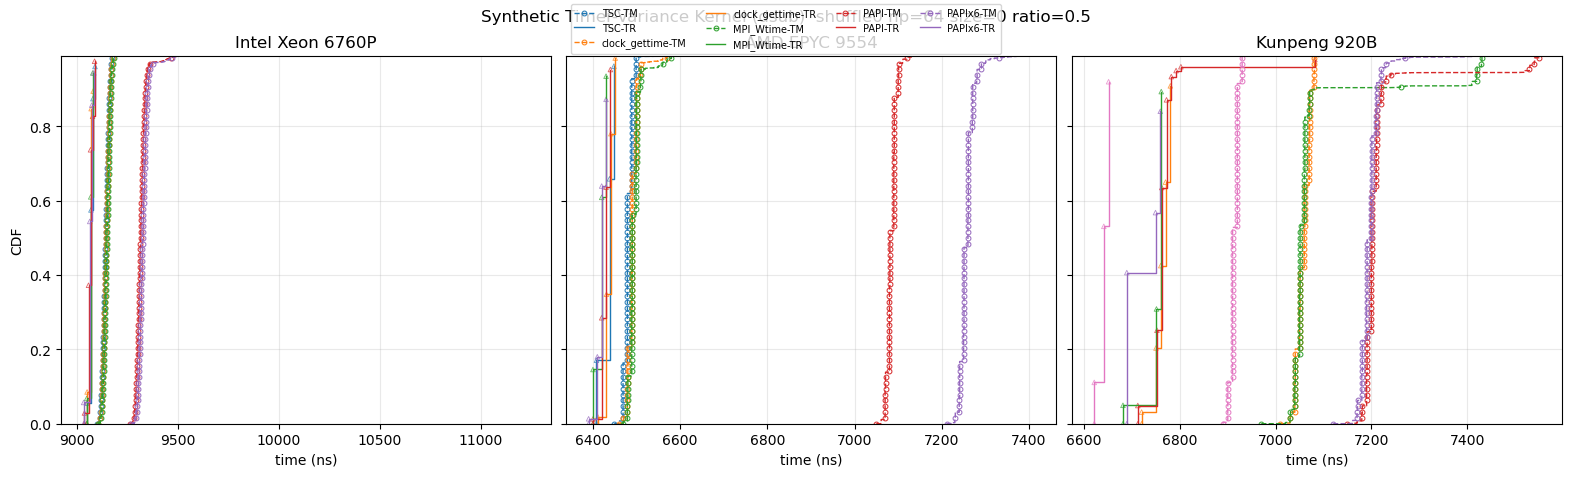

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size512_ratio0.5_tm_tr_mark.png


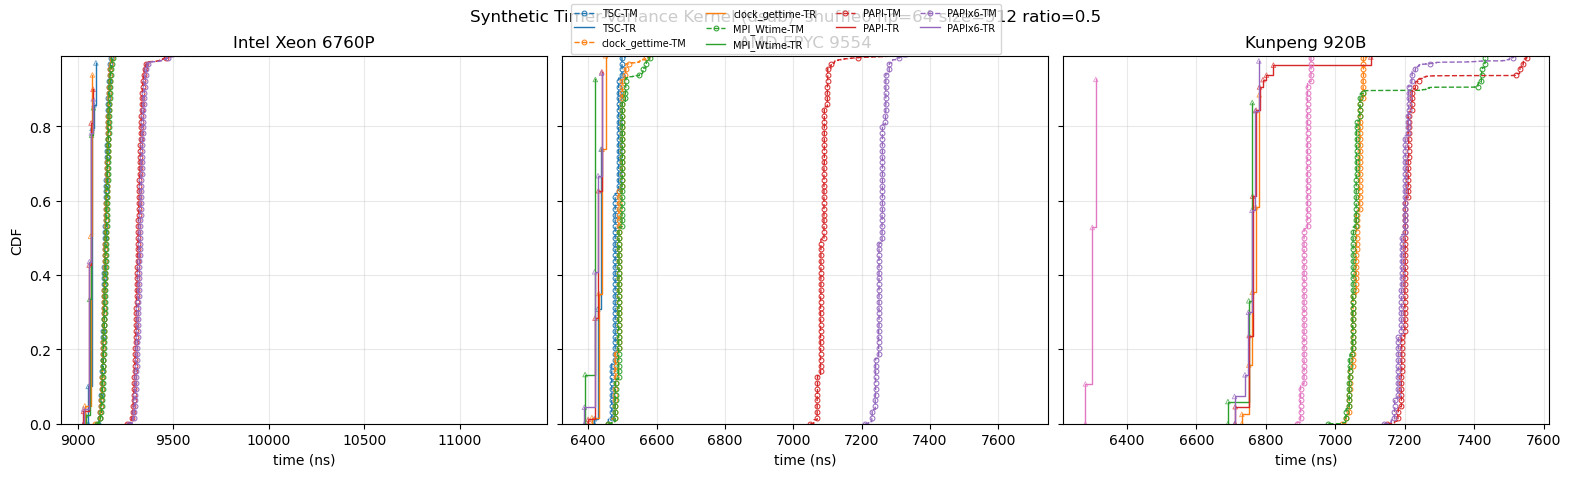

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size1024_ratio0.5_tm_tr_mark.png


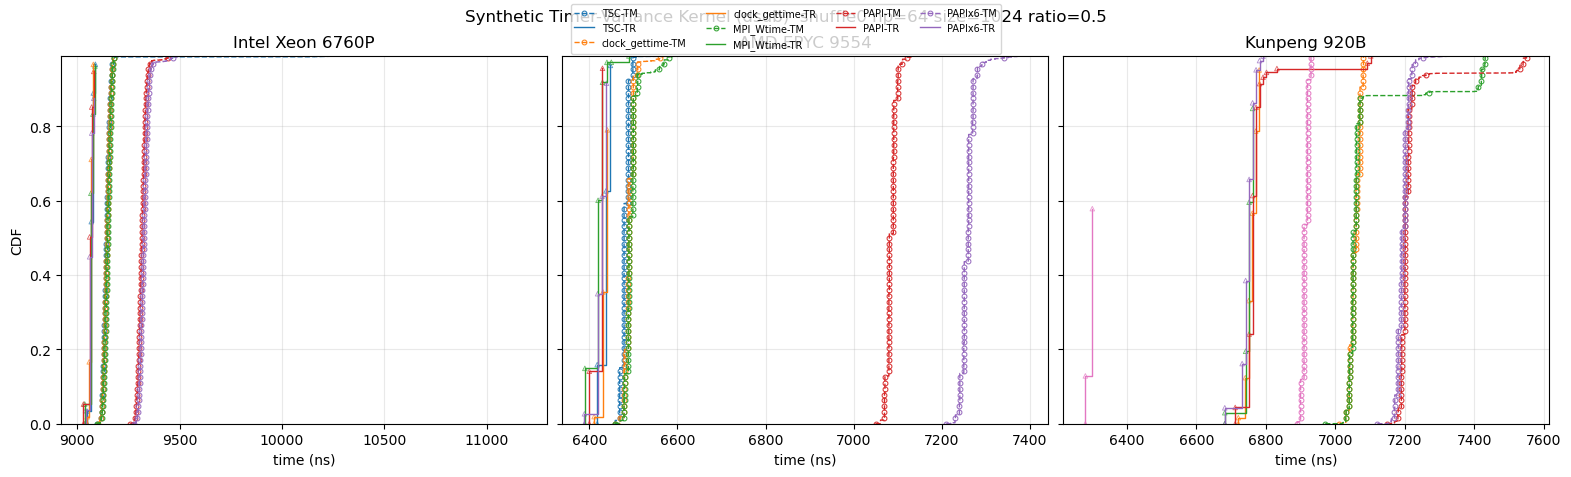

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size2048_ratio0.5_tm_tr_mark.png


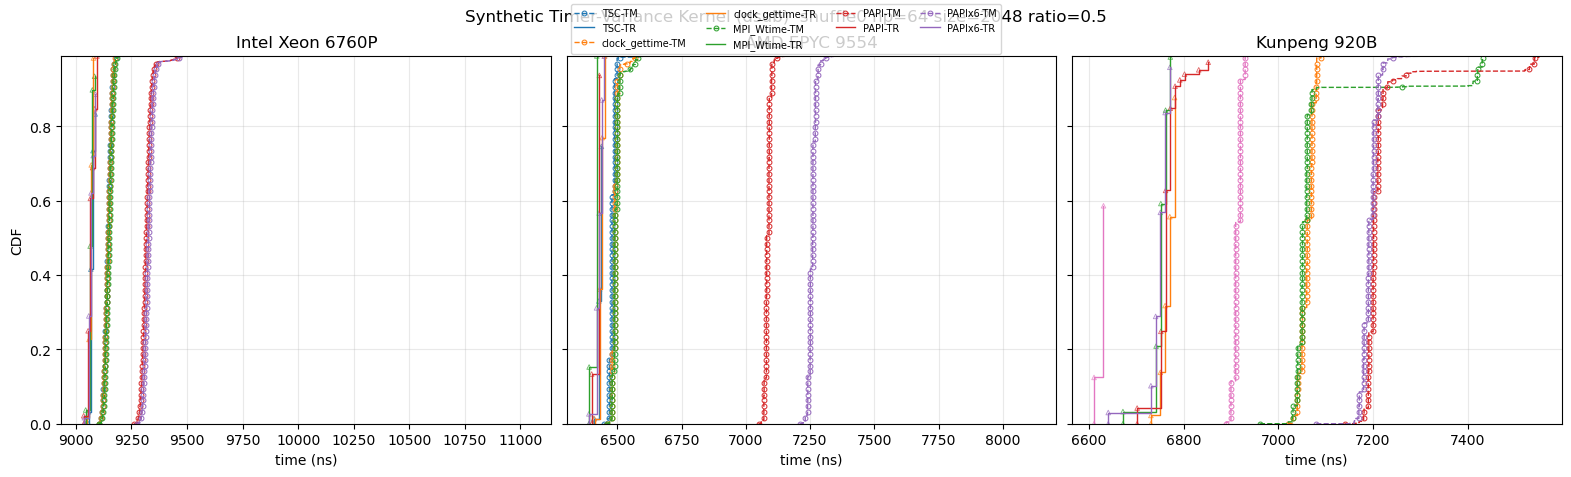

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size4096_ratio0.5_tm_tr_mark.png


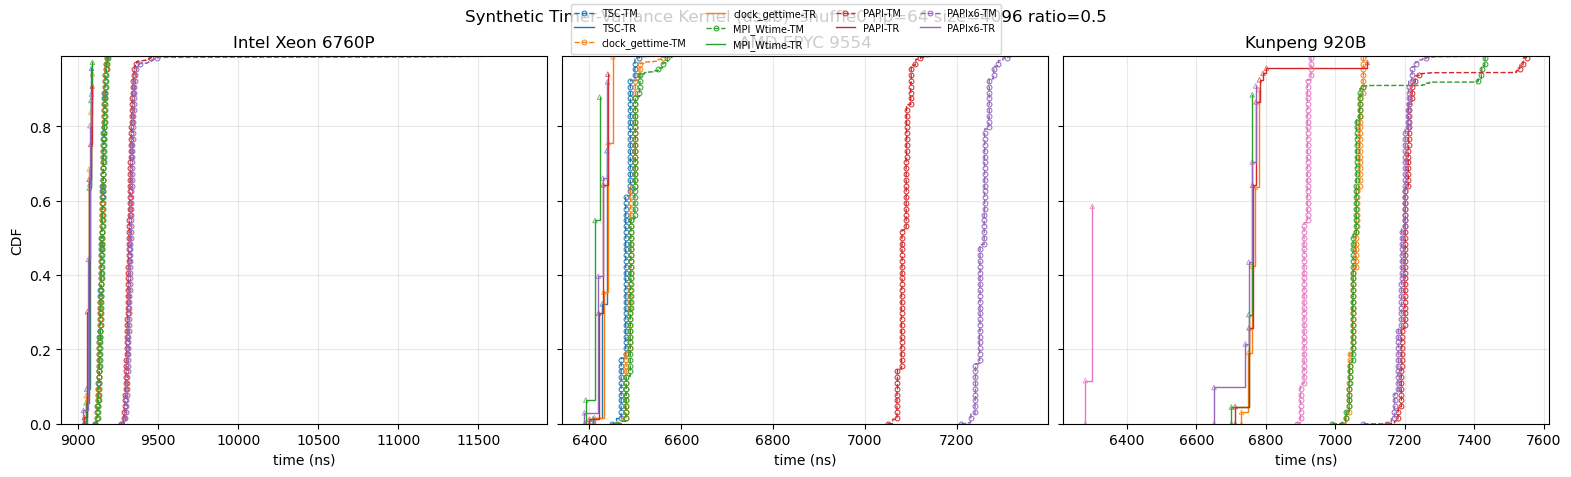

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size8192_ratio0.5_tm_tr_mark.png


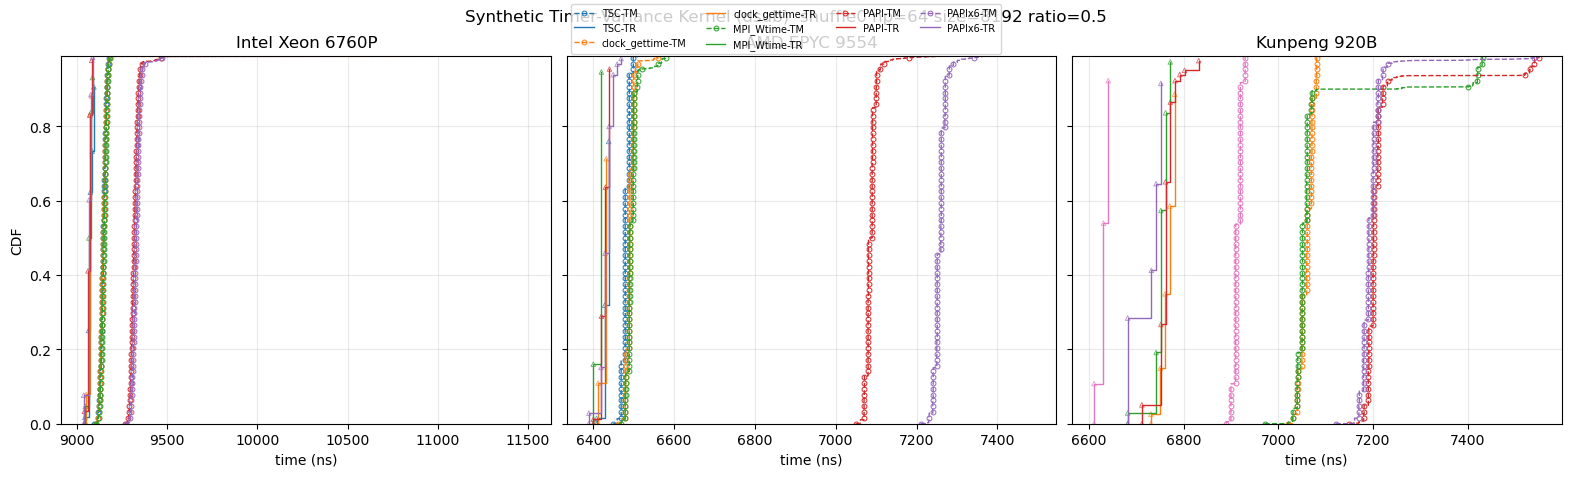

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size0_ratio0.8_tm_tr_mark.png


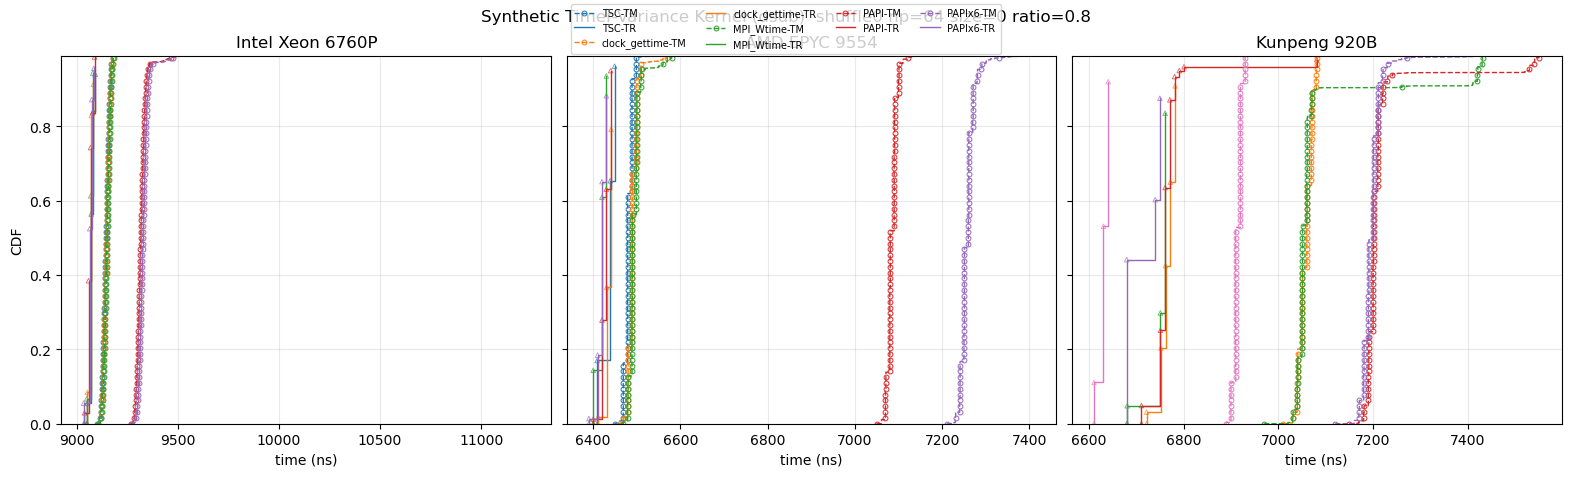

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size512_ratio0.8_tm_tr_mark.png


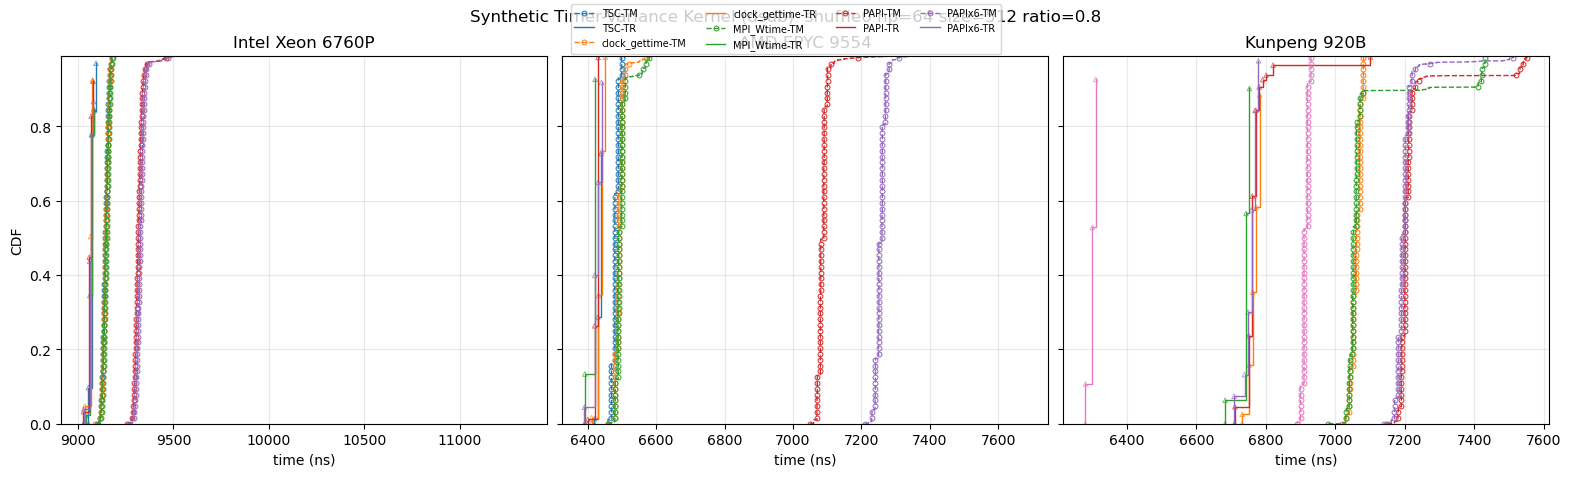

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size1024_ratio0.8_tm_tr_mark.png


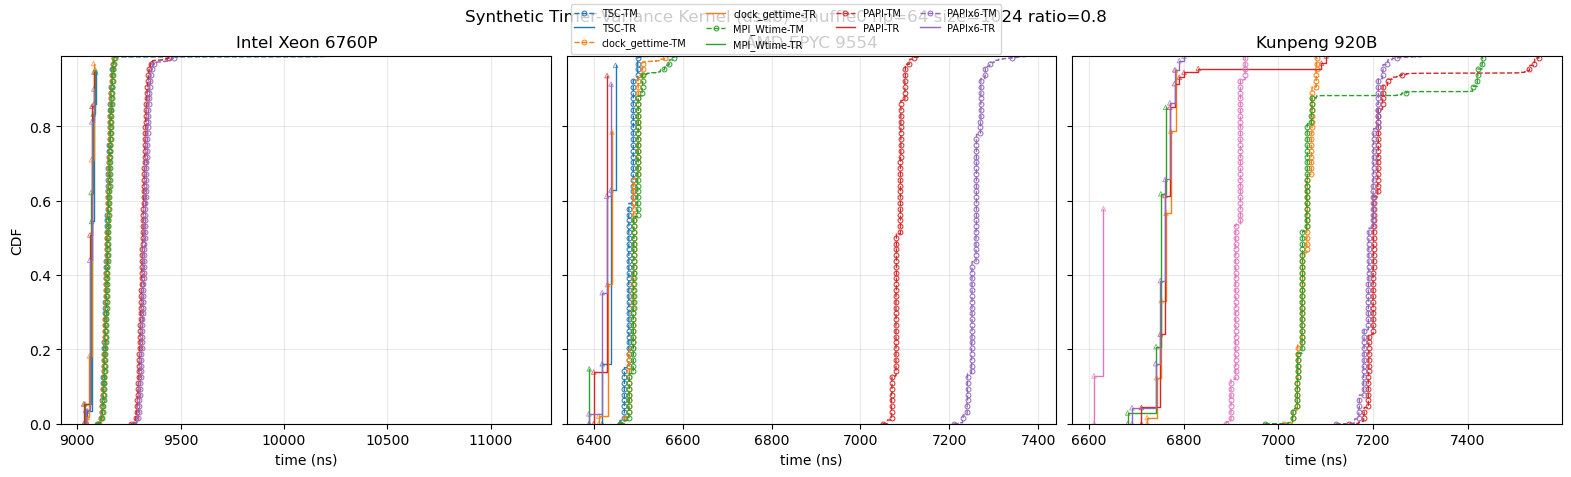

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size2048_ratio0.8_tm_tr_mark.png


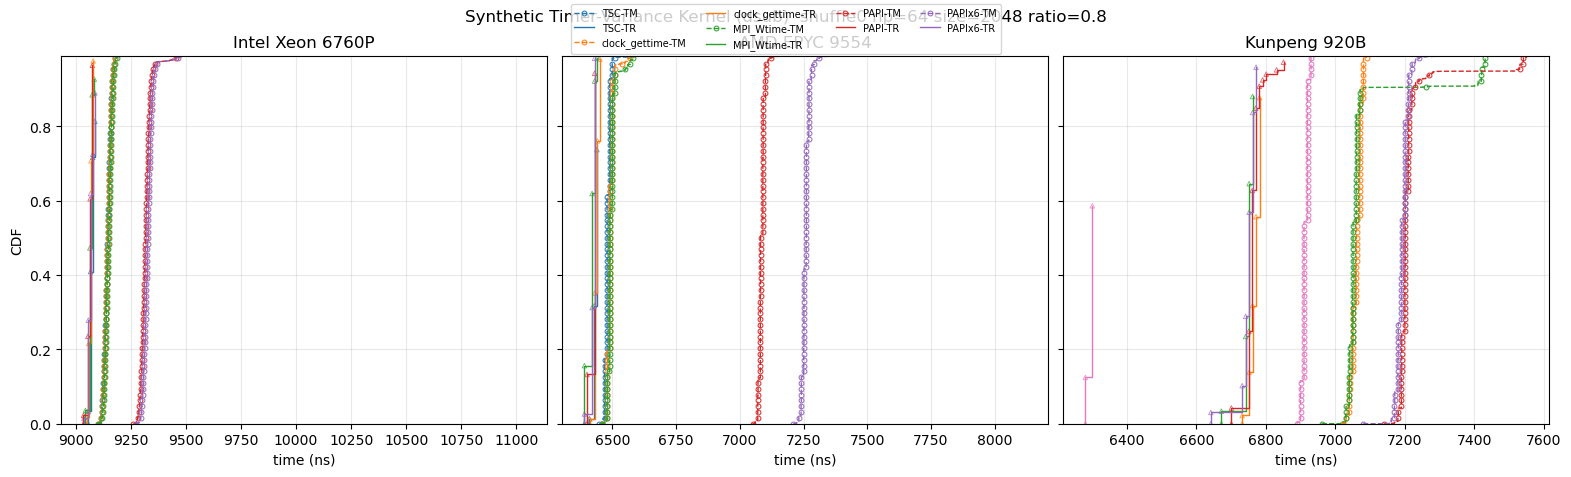

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size4096_ratio0.8_tm_tr_mark.png


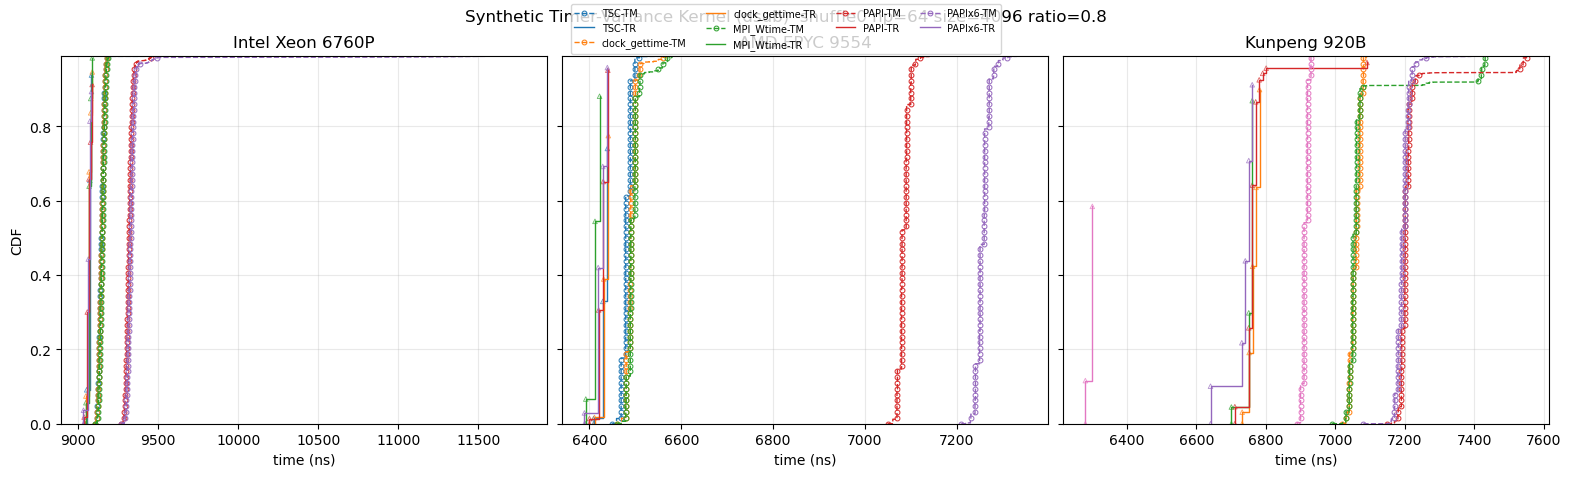

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0614_tvkern_dsub/tvkern_dsub_shuffle0_np64_size8192_ratio0.8_tm_tr_mark.png


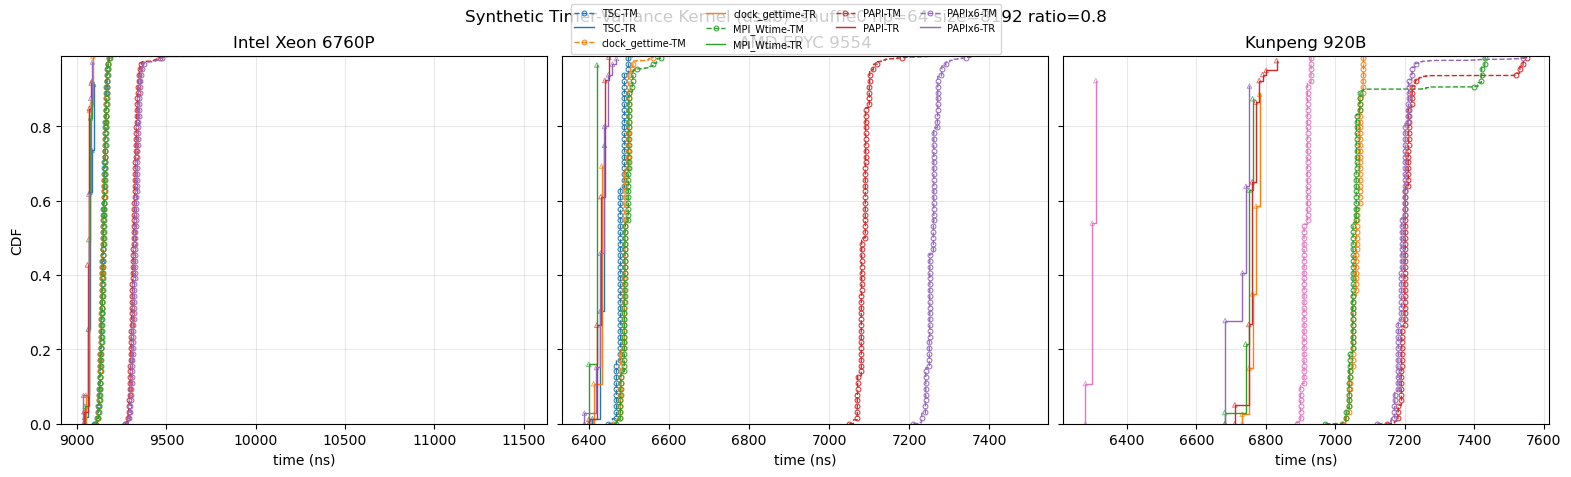

In [6]:
PLOT_SIZES = [0, 512, 1024, 2048, 4096, 8192]

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

for ratio in sorted(entries['ratio'].dropna().unique()):
    for size in PLOT_SIZES:
        entries_plot = entries[(entries['ratio'] == ratio) & (entries['size'] == size)]
        if entries_plot.empty:
            continue

        for (kernel, np_val), group_all in entries_plot.groupby(['kernel', 'np'], sort=True):
            hosts = [host for host in HOST_ORDER if host in set(group_all['host'])]
            if not hosts:
                continue
            fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4.4), sharey=True, constrained_layout=True)
            axes = np.atleast_1d(axes)

            for ax, host in zip(axes, hosts):
                group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))
                for _, row in group.iterrows():
                    timer = row['timer']
                    color = TIMER_COLORS.get(timer)
                    label = timer_label(timer)

                    tm_x, tm_y = ecdf_xy(read_tm(row['tm_file']))
                    tr_df = read_hist(row['tr_hist_file'])

                    tm_markevery = max(10, len(tm_x) // 100)
                    tm_markevery = 1000

                    tr_ns = tr_df['ns'].to_numpy()
                    tr_cdf = tr_df['cdf'].to_numpy()
                    if len(tr_ns) > TR_MARKER_MAX:
                        keep = np.linspace(0, len(tr_ns) - 1, TR_MARKER_MAX, dtype=int)
                        tr_marker_x = tr_ns[keep]
                        tr_marker_y = tr_cdf[keep]
                    else:
                        tr_marker_x = tr_ns
                        tr_marker_y = tr_cdf

                    ax.step(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, where='post', marker='.', markevery=tm_markevery, markersize=7, markerfacecolor='none', markeredgewidth=0.7)
                    tr_x_step = np.repeat(tr_ns, 2)[1:]
                    tr_y_step = np.repeat(tr_cdf, 2)[:-1]
                    ax.plot(tr_x_step, tr_y_step, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0)
                    ax.scatter(tr_marker_x, tr_marker_y, color=color, marker='^', s=11, linewidths=0.6, facecolor='none', alpha=0.72)

                ax.set_title(HOST_LABELS.get(host, host))
                ax.set_xlabel('time (ns)')
                ax.set_ylim(0, QUANTILE_DROP)
                ax.grid(True, alpha=0.28)
                if ax is axes[0]:
                    ax.set_ylabel('CDF')

            handles, labels = axes[0].get_legend_handles_labels()
            fig.legend(handles, labels, ncol=min(4, max(1, len(labels))), fontsize=7, loc='upper center')
            fig.suptitle(f'{KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_SELECT} np={np_val} size={size} ratio={ratio:g}', y=1.05)

            if SAVE_FIG:
                out = OUT_DIR / f'{kernel}_dsub_{SHUFFLE_SELECT}_np{np_val}_size{size}_ratio{ratio:g}_tm_tr_mark.png'
                fig.savefig(out, dpi=220, bbox_inches='tight')
                print(out)
            plt.show()


In [7]:
(df.groupby(['ratio', 'size'])['timer']
   .nunique()
   .unstack('ratio')
   .fillna(0)
   .astype(int))


ratio,0.5,0.8
size,,
0,6,6
16,6,6
32,6,6
64,6,6
128,6,6
256,6,6
512,6,6
1024,6,6
2048,6,6
